In [17]:
import pandas as pd
import numpy as np

from imblearn.over_sampling import SMOTE

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import auc, roc_curve

import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.metrics import precision_recall_curve, average_precision_score

In [18]:
#Data importation
data = pd.read_csv("/Users/Main/Downloads/Fraud/bs140513_032310.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   step         594643 non-null  int64  
 1   customer     594643 non-null  object 
 2   age          594643 non-null  object 
 3   gender       594643 non-null  object 
 4   zipcodeOri   594643 non-null  object 
 5   merchant     594643 non-null  object 
 6   zipMerchant  594643 non-null  object 
 7   category     594643 non-null  object 
 8   amount       594643 non-null  float64
 9   fraud        594643 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 45.4+ MB


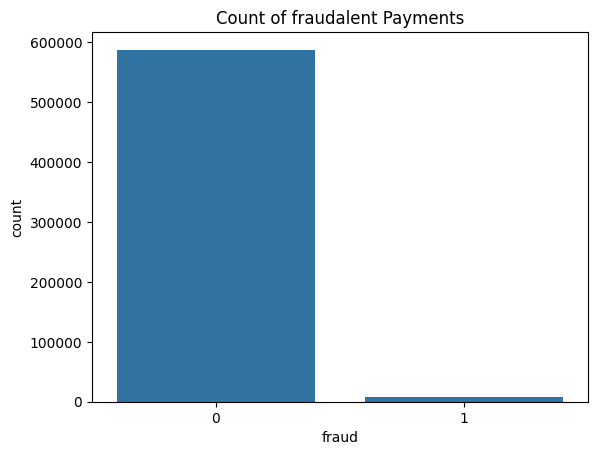

In [ ]:
#EDA
df_fraud = data.loc[data.fraud == 1]
df_non_fraud = data.loc[data.fraud == 0]

sns.countplot(x='Fraud', data=data)
plt.title("Count of Fraudalent Payments")
plt.show()

In [20]:
pd.concat([df_fraud.groupby('category')['amount'].sum(), df_non_fraud.groupby('category')['amount'].sum(), data.groupby('category')['fraud'].mean()*100], keys=["Fraudulent","Non-Fraudulent","Percent(%)"],axis=1)

,Fraudulent,Non-Fraudulent,Percent(%)
category,,,
'es_barsandrestaurants',19691.12,257285.92,1.882944
'es_fashion',28652.95,395159.56,1.797335
'es_health',690325.15,1497654.36,10.512614
'es_home',138160.42,190861.88,15.206445
'es_hotelservices',231159.19,127432.06,31.422018
'es_hyper',47391.52,232936.11,4.591669
'es_leisure',142335.98,1830.76,94.989980
'es_otherservices',72155.07,51768.88,25.000000
'es_sportsandtoys',684517.02,178775.53,49.525237


/var/folders/2n/lfgz4hr5525103457853j94c0000gn/T/ipykernel_723/4273913923.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


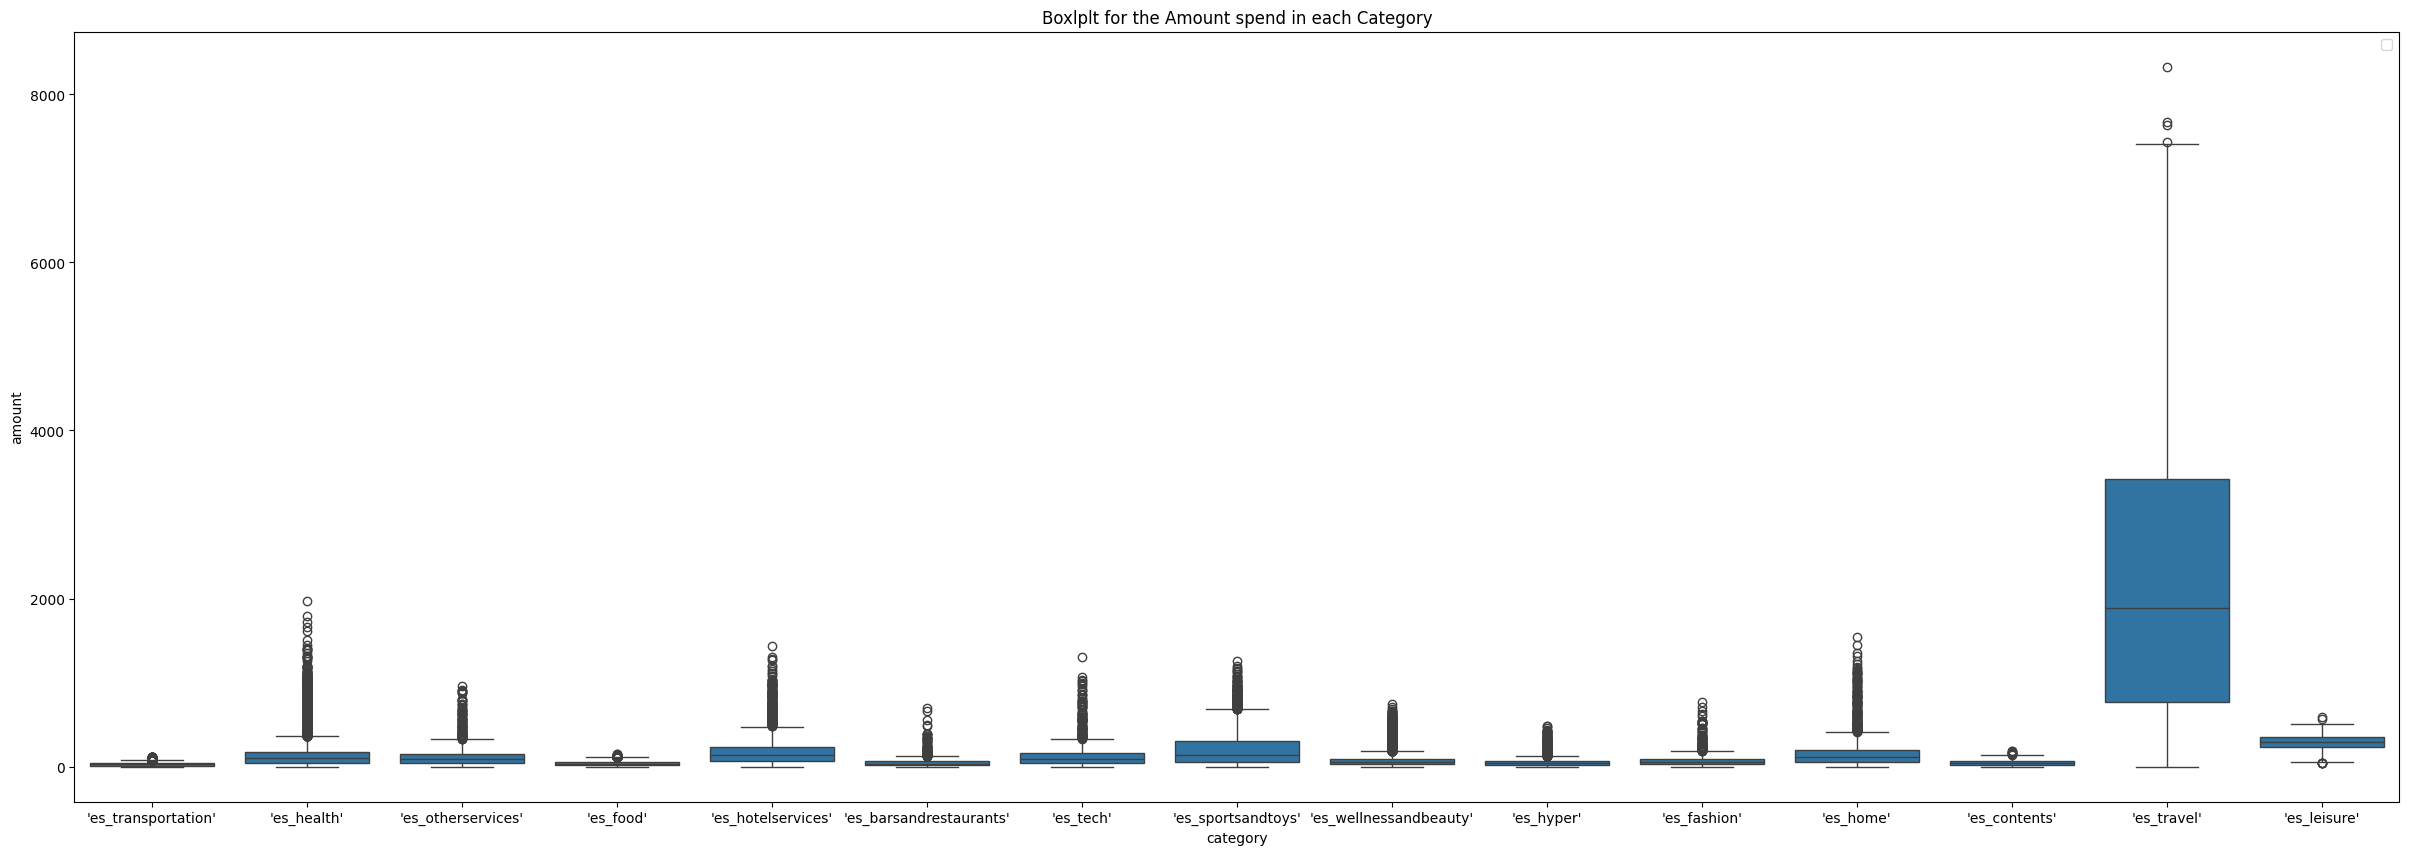

In [21]:
plt.figure(figsize=(30,10))
sns.boxplot(x=data.category, y=data.amount)
plt.title("Boxlplt for the Amount spend in each Category")
plt.legend()
plt.show()

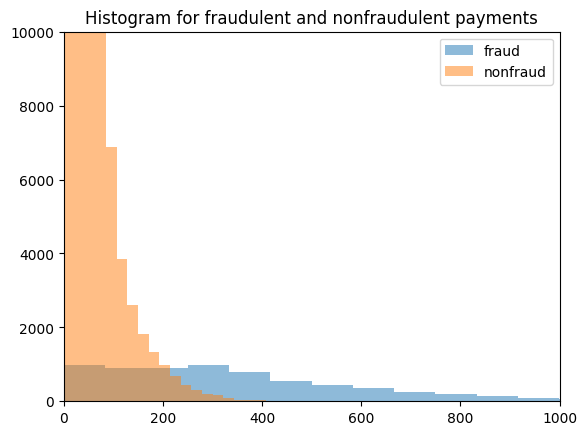

In [22]:
plt.hist(df_fraud.amount, alpha=0.5, label='fraud',bins=100)
plt.hist(df_non_fraud.amount, alpha=0.5, label='nonfraud',bins=100)
plt.title("Histogram for fraudulent and nonfraudulent payments")
plt.ylim(0,10000)
plt.xlim(0,1000)
plt.legend()
plt.show()

In [23]:
df_gender = pd.concat([df_fraud.groupby('gender')['amount'].sum(), df_non_fraud.groupby('gender')['amount'].sum(), data.groupby('gender')['fraud'].mean()*100], keys=["Fraudulent","Non-Fraudulent","Percent(%)"],axis=1)

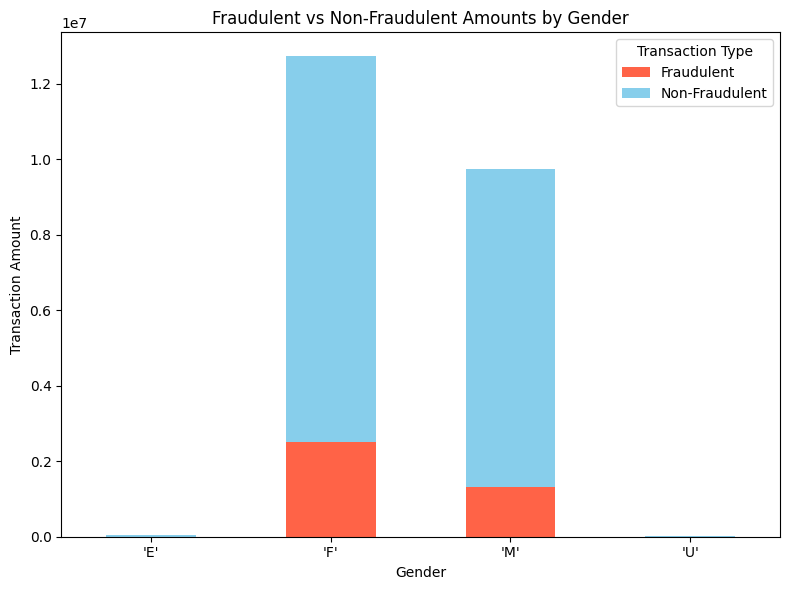

In [24]:
ax = df_gender[["Fraudulent", "Non-Fraudulent"]].plot(
    kind = "bar",
    stacked = True,
    figsize=(8,6),
    color = ['tomato', 'skyblue']
)

plt.title('Fraudulent vs Non-Fraudulent Amounts by Gender')
plt.ylabel('Transaction Amount')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.legend(title='Transaction Type')
plt.tight_layout()
plt.show()

In [25]:
#Data cleaning and processing
print("Unique zipCodeOri values: ",data.zipcodeOri.nunique())
print("Unique zipMerchant values: ",data.zipMerchant.nunique())
# dropping zipcodeori and zipMerchant since they have only one unique value
data_reduced = data.drop(['zipcodeOri','zipMerchant'],axis=1)

Unique zipCodeOri values:  1
Unique zipMerchant values:  1


In [26]:
col_categorical = data_reduced.select_dtypes(include = ['object']).columns
for col in col_categorical:
    data_reduced[col] = data_reduced[col].astype('category')
data_reduced[col_categorical] = data_reduced[col_categorical].apply(lambda x: x.cat.codes)
data_reduced.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   step      594643 non-null  int64  
 1   customer  594643 non-null  int16  
 2   age       594643 non-null  int8   
 3   gender    594643 non-null  int8   
 4   merchant  594643 non-null  int8   
 5   category  594643 non-null  int8   
 6   amount    594643 non-null  float64
 7   fraud     594643 non-null  int64  
dtypes: float64(1), int16(1), int64(2), int8(4)
memory usage: 17.0 MB


In [27]:
X = data_reduced.drop(['fraud'], axis = 1)
y = data['fraud']

In [28]:
#Oversampling
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
y_res = pd.DataFrame(y_res)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X_res,y_res,test_size=0.3,random_state=42,shuffle=True,stratify=y_res)

In [30]:
#Function for plotting ROC_AUC curve
def plot_roc_auc(y_test, preds):
    fpr, tpr, threshold = roc_curve(y_test, preds)
    roc_auc = auc(fpr, tpr)
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

In [31]:
def tune_threshold(y_true, y_probs):
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)
    fscore = (2 * precision * recall) / (precision + recall + 1e-9)
    ix = np.argmax(fscore)
    print(f"Best Threshold={thresholds[ix]:.3f}, F1={fscore[ix]:.3f}, Precision={precision[ix]:.3f}, Recall={recall[ix]:.3f}")
    return thresholds[ix], precision, recall, fscore

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.90      0.95      0.92    176233
           1       0.95      0.89      0.92    176233

    accuracy                           0.92    352466
   macro avg       0.92      0.92      0.92    352466
weighted avg       0.92      0.92      0.92    352466

Confusion Matrix:
 [[167233   9000]
 [ 18680 157553]]


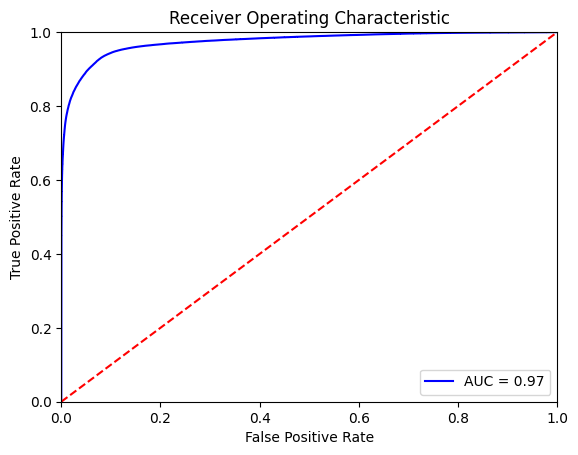

In [32]:
#Logistic Regression
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_probs_lr = log_reg.predict_proba(X_test)[:, 1]
y_pred_lr = (y_probs_lr >= 0.5).astype(int)

print("\n=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
plot_roc_auc(y_test, y_probs_lr)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    176233
           1       0.97      1.00      0.98    176233

    accuracy                           0.98    352466
   macro avg       0.98      0.98      0.98    352466
weighted avg       0.98      0.98      0.98    352466

Confusion Matrix:
 [[170965   5268]
 [   781 175452]]


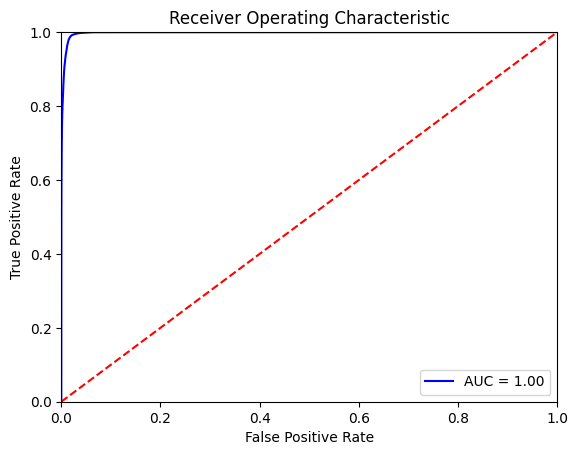

In [33]:
#Random forest classifier
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)
y_probs_rf = rf_clf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_probs_rf >= 0.5).astype(int)

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
plot_roc_auc(y_test, y_probs_rf)


=== XGBoost ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    176233
           1       0.99      1.00      0.99    176233

    accuracy                           0.99    352466
   macro avg       0.99      0.99      0.99    352466
weighted avg       0.99      0.99      0.99    352466

Confusion Matrix:
 [[174061   2172]
 [   728 175505]]


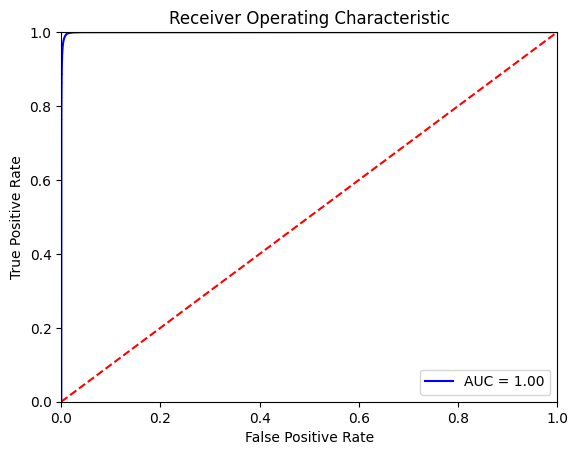

In [34]:
scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])

XGBoost_CLF = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.05,
    n_estimators=400,
    objective="binary:logistic",  # probability output
    booster="gbtree",
    n_jobs=-1,
    gamma=0,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    scale_pos_weight=scale_pos_weight,  # handle imbalance
    random_state=42,
    verbosity=0
)

XGBoost_CLF.fit(X_train, y_train)
y_probs_xgb = XGBoost_CLF.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_probs_xgb >= 0.5).astype(int)

print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
plot_roc_auc(y_test, y_probs_xgb)



=== XGBoost ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    176233
           1       0.99      1.00      0.99    176233

    accuracy                           0.99    352466
   macro avg       0.99      0.99      0.99    352466
weighted avg       0.99      0.99      0.99    352466

Confusion Matrix:
 [[174061   2172]
 [   728 175505]]


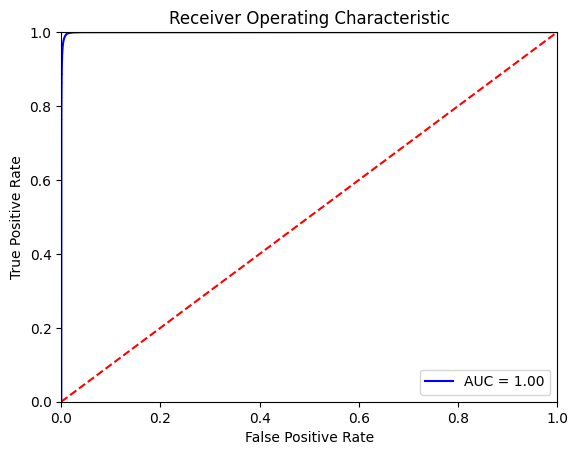

In [35]:
scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])

XGBoost_CLF = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.05,
    n_estimators=400,
    objective="binary:logistic",  # probability output
    booster="gbtree",
    n_jobs=-1,
    gamma=0,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    scale_pos_weight=scale_pos_weight,  # handle imbalance
    random_state=42,
    verbosity=0
)

XGBoost_CLF.fit(X_train, y_train)
y_probs_xgb = XGBoost_CLF.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_probs_xgb >= 0.5).astype(int)

print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
plot_roc_auc(y_test, y_probs_xgb)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)



=== Voting Ensemble (LR + RF + XGB) ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.99    176233
           1       0.98      0.99      0.99    176233

    accuracy                           0.99    352466
   macro avg       0.99      0.99      0.99    352466
weighted avg       0.99      0.99      0.99    352466

Confusion Matrix:
 [[172942   3291]
 [  1220 175013]]


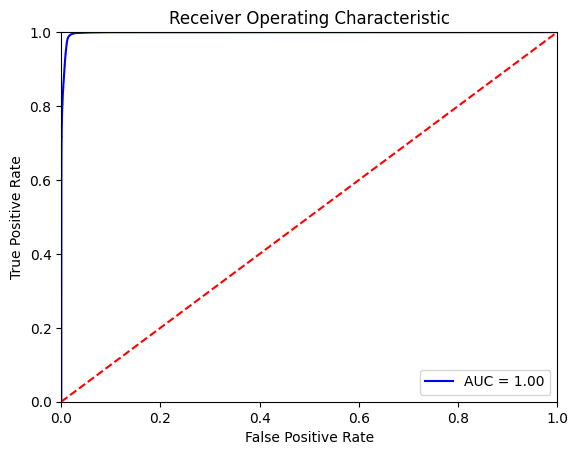

In [36]:
voting_clf = VotingClassifier(
    estimators=[("lr", log_reg), ("rf", rf_clf), ("xgb", XGBoost_CLF)],
    voting="soft",
    n_jobs=-1
)

voting_clf.fit(X_train, y_train)
y_probs_vote = voting_clf.predict_proba(X_test)[:, 1]
y_pred_vote = (y_probs_vote >= 0.5).astype(int)

print("\n=== Voting Ensemble (LR + RF + XGB) ===")
print(classification_report(y_test, y_pred_vote))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_vote))
plot_roc_auc(y_test, y_probs_vote)

In [37]:
def evaluate_model(name, y_true, y_probs, threshold=0.5):
    # Predictions
    y_pred = (y_probs >= threshold).astype(int)
    
    # Metrics
    roc = roc_auc_score(y_true, y_probs)
    pr_auc = average_precision_score(y_true, y_probs)
    report = classification_report(y_true, y_pred, output_dict=True)
    
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    
    return {
        "Model": name,
        "ROC AUC": roc,
        "PR AUC": pr_auc,
        "F1": report["1"]["f1-score"],
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"]
    }


In [38]:
results = []

results.append(evaluate_model("LogReg", y_test, y_probs_lr))
results.append(evaluate_model("RandomForest", y_test, y_probs_rf))
results.append(evaluate_model("XGBoost", y_test, y_probs_xgb))
results.append(evaluate_model("Voting", y_test, y_probs_vote))

import pandas as pd
df_results = pd.DataFrame(results)
print(df_results)


          Model   ROC AUC    PR AUC        F1  Precision    Recall
0        LogReg  0.974466  0.978580  0.919250   0.945963  0.894004
1  RandomForest  0.998034  0.997812  0.983054   0.970850  0.995568
2       XGBoost  0.999513  0.999487  0.991806   0.987776  0.995869
3        Voting  0.998254  0.998112  0.987276   0.981543  0.993077


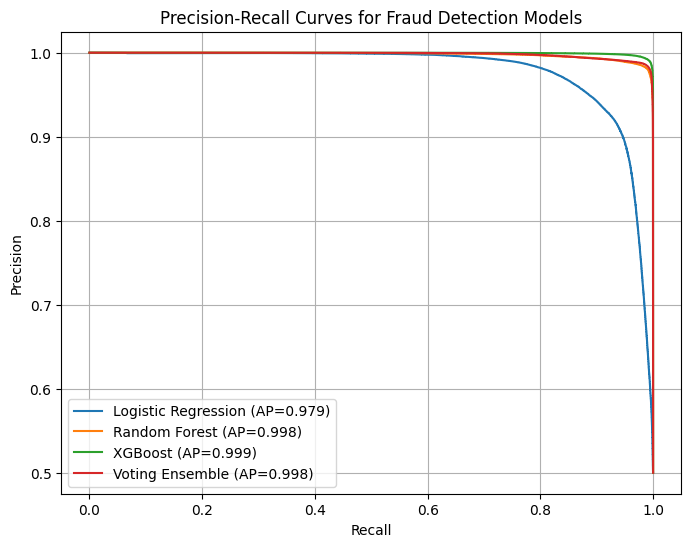

In [40]:

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": y_probs_lr,
    "Random Forest": y_probs_rf,
    "XGBoost": y_probs_xgb,
    "Voting Ensemble": y_probs_vote
}

for name, y_probs in models.items():
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    pr_auc = average_precision_score(y_test, y_probs)
    plt.plot(recall, precision, label=f"{name} (AP={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for Fraud Detection Models")
plt.legend()
plt.grid(True)
plt.show()
